# Two-Player League Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
data_path = Path("../../results/league_results/2p/matches.csv")

df = pd.read_csv(data_path)
model_aliases = {
    "fixed_2p": "DQN 2P",
    "variable_2_4": "DQN 2-4P",
    "variable_encoder_2_4": "DQN 2-4P + Encoder",
}
df["point_margin"] = df["points"] - df["opponent_points"]
df["won"] = df["outcome"].eq("win")
df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_label"] = df["opponent_competitor"].map(model_aliases)

## Pairwise Results

In [2]:
pairwise = (
    df.groupby(["competitor_label", "opponent_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
pairwise.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})

,competitor_label,opponent_label,games,wins,losses,ties,raw_win_rate,mean_points,mean_margin
0,DQN 2-4P,DQN 2-4P,600,296,296,8,49.3%,55.80,+0.00
1,DQN 2-4P,DQN 2-4P + Encoder,900,311,577,12,34.6%,54.53,-3.10
2,DQN 2-4P,DQN 2P,900,435,452,13,48.3%,55.87,-0.54
3,DQN 2-4P + Encoder,DQN 2-4P,900,577,311,12,64.1%,57.63,+3.10
4,DQN 2-4P + Encoder,DQN 2-4P + Encoder,600,297,297,6,49.5%,56.53,+0.00
5,DQN 2-4P + Encoder,DQN 2P,900,551,341,8,61.2%,57.53,+2.71
6,DQN 2P,DQN 2-4P,900,452,435,13,50.2%,56.41,+0.54
7,DQN 2P,DQN 2-4P + Encoder,900,341,551,8,37.9%,54.82,-2.71
8,DQN 2P,DQN 2P,600,300,300,0,50.0%,55.69,+0.00


## Head-to-Head

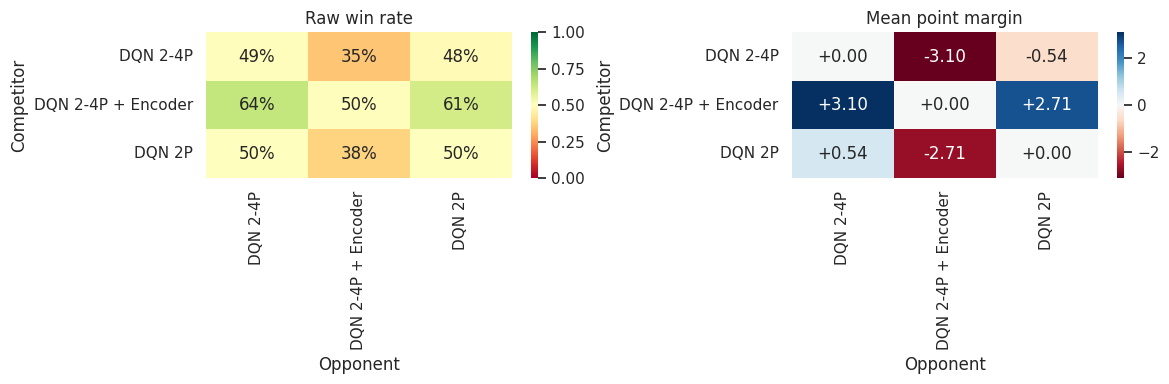

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

win_matrix = pairwise.pivot(
    index="competitor_label", columns="opponent_label", values="raw_win_rate"
)
margin_matrix = pairwise.pivot(
    index="competitor_label", columns="opponent_label", values="mean_margin"
)

sns.heatmap(win_matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=axes[0])
axes[0].set_title("Raw win rate")
sns.heatmap(margin_matrix, annot=True, fmt="+.2f", center=0, cmap="RdBu", ax=axes[1])
axes[1].set_title("Mean point margin")
for ax in axes:
    ax.set_xlabel("Opponent")
    ax.set_ylabel("Competitor")
plt.tight_layout()

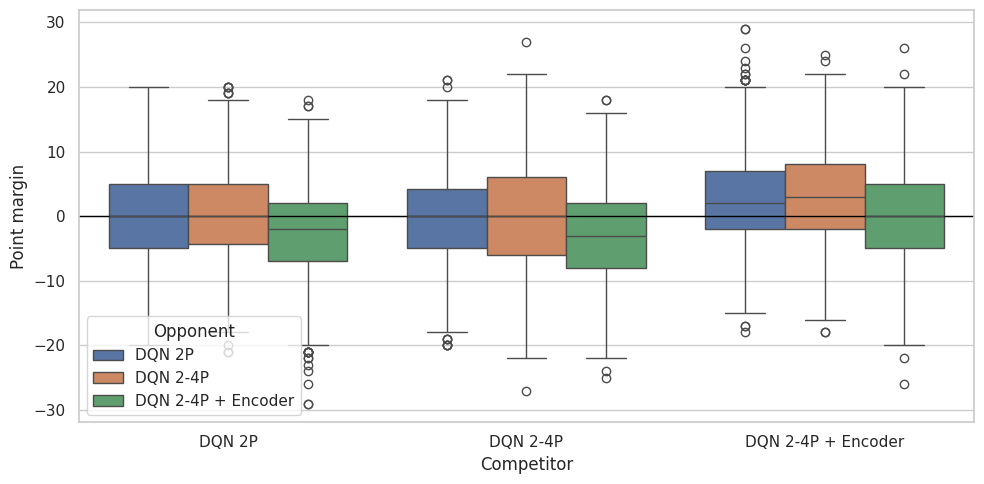

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="competitor_label", y="point_margin", hue="opponent_label")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Competitor")
plt.ylabel("Point margin")
plt.legend(title="Opponent")
plt.tight_layout()

## Overall Results

In [5]:
overall = (
    df.groupby("competitor_label")
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .sort_values("raw_win_rate", ascending=False)
)
overall.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})

,games,wins,losses,ties,raw_win_rate,mean_points,mean_margin
competitor_label,,,,,,,
DQN 2-4P + Encoder,2400,1425,949,26,59.4%,57.32,+2.18
DQN 2P,2400,1093,1286,21,45.5%,55.63,-0.81
DQN 2-4P,2400,1042,1325,33,43.4%,55.35,-1.37


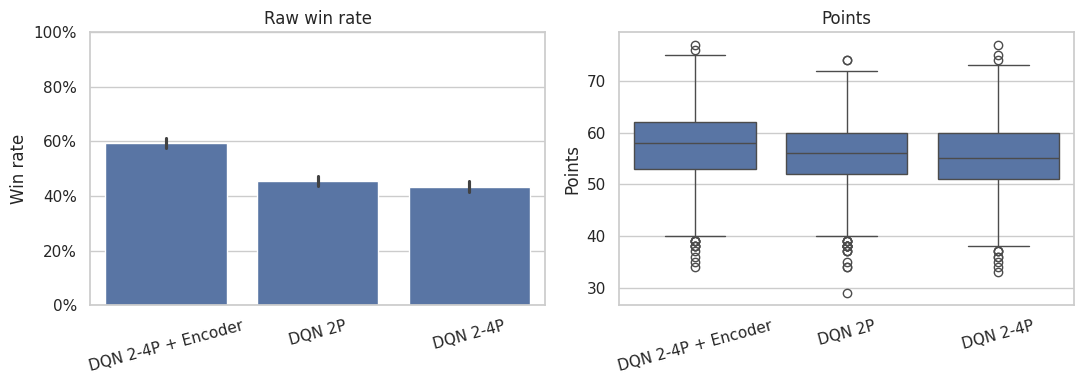

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = overall.index

sns.barplot(data=df, x="competitor_label", y="won", order=order, errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("Raw win rate")
axes[0].set_xlabel("")
axes[0].set_ylabel("Win rate")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

sns.boxplot(data=df, x="competitor_label", y="points", order=order, ax=axes[1])
axes[1].set_title("Points")
axes[1].set_xlabel("")
axes[1].set_ylabel("Points")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()

## Repetition Variance

In [7]:
repetition_win_rates = (
    df.groupby(["competitor_label", "repetition"])
      .agg(
          games=("match_id", "size"),
          raw_win_rate=("won", "mean"),
      )
      .reset_index()
)

win_rate_variance = (
    repetition_win_rates.groupby("competitor_label")
      .agg(
          repetitions=("repetition", "nunique"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
win_rate_variance["win_rate_variance"] = win_rate_variance["win_rate_variance"].fillna(0)

win_rate_variance.style.format({
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})

,competitor_label,repetitions,mean_win_rate,win_rate_variance
0,DQN 2-4P,3,43.4%,0.0010
1,DQN 2-4P + Encoder,3,59.4%,0.0027
2,DQN 2P,3,45.5%,0.0012


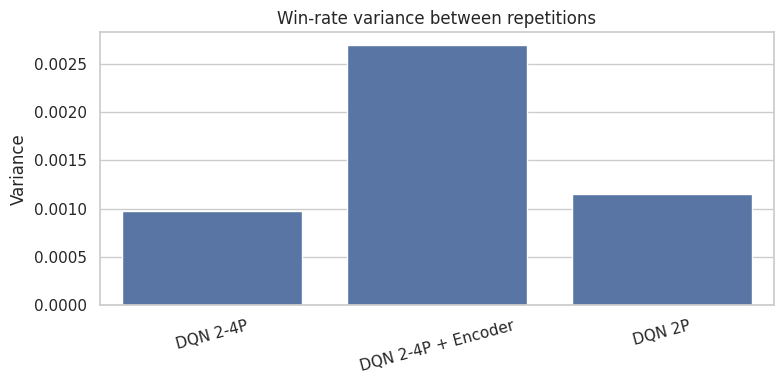

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(data=win_rate_variance, x="competitor_label", y="win_rate_variance")
plt.title("Win-rate variance between repetitions")
plt.xlabel("")
plt.ylabel("Variance")
plt.xticks(rotation=15)
plt.tight_layout()

## Seat Effects

In [9]:
seat_results = (
    df.groupby(["competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,competitor_label,seat,games,raw_win_rate,mean_margin
0,DQN 2-4P,0,1199,43.5%,-1.47
1,DQN 2-4P,1,1201,43.4%,-1.26
2,DQN 2-4P + Encoder,0,1166,60.1%,+2.16
3,DQN 2-4P + Encoder,1,1234,58.7%,+2.20
4,DQN 2P,0,1235,46.3%,-0.70
5,DQN 2P,1,1165,44.7%,-0.93


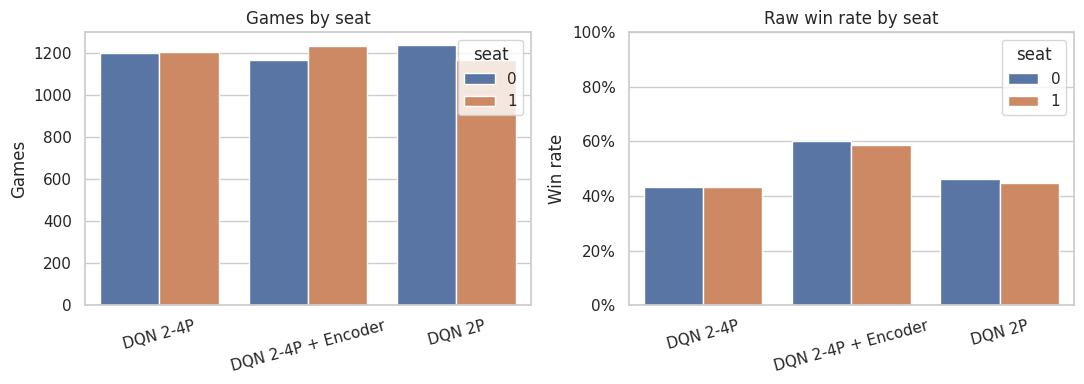

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=seat_results, x="competitor_label", y="games", hue="seat", ax=axes[0])
axes[0].set_title("Games by seat")
axes[0].set_xlabel("")
axes[0].set_ylabel("Games")

sns.barplot(data=seat_results, x="competitor_label", y="raw_win_rate", hue="seat", ax=axes[1])
axes[1].set_title("Raw win rate by seat")
axes[1].set_xlabel("")
axes[1].set_ylabel("Win rate")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()

## Training Metrics

In [11]:
metrics_candidates = [Path("results/league"), Path("../../results/league")]
metrics_root = next(path for path in metrics_candidates if path.exists())

training_metrics = []
for model, alias in model_aliases.items():
    for metrics_path in sorted((metrics_root / model).glob("repetition_*/metrics.csv")):
        metrics = pd.read_csv(metrics_path)
        metrics["model"] = alias
        metrics["repetition"] = int(metrics_path.parent.name.removeprefix("repetition_"))
        training_metrics.append(metrics)

training_df = pd.concat(training_metrics, ignore_index=True)
training_df["loss_smoothed"] = training_df.groupby(["model", "repetition"])["loss"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)
training_df["return_smoothed"] = training_df.groupby(["model", "repetition"])["mean_episode_return"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)

KeyboardInterrupt: 

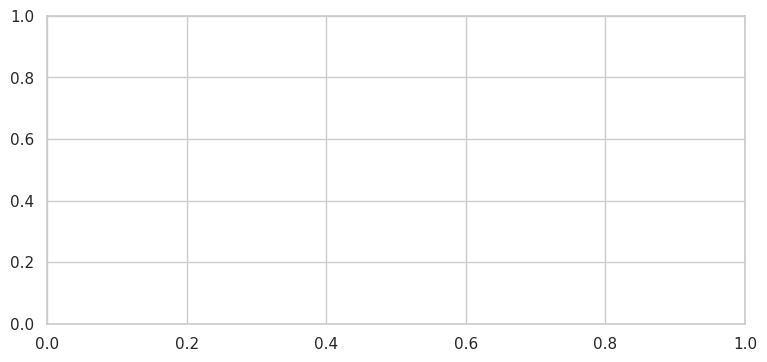

In [12]:
plt.figure(figsize=(9, 4))
sns.lineplot(data=training_df, x="iteration", y="loss_smoothed", hue="model")
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (100-iteration mean)")
plt.legend(title="")
plt.tight_layout()

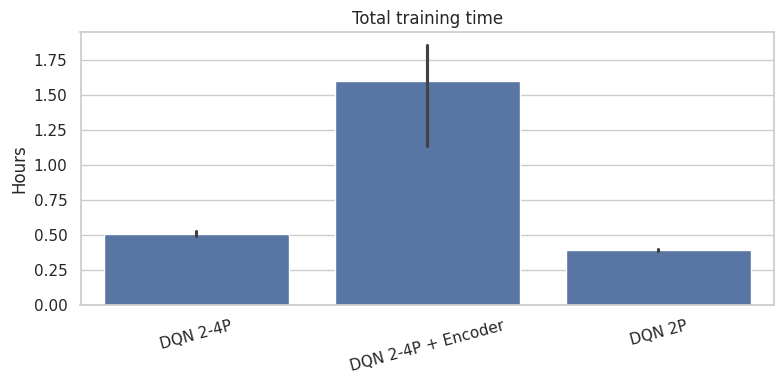

In [ ]:
training_time = (
    training_df.groupby(["model", "repetition"], as_index=False)["elapsed_seconds"].max()
)
training_time["hours"] = training_time["elapsed_seconds"] / 3600

plt.figure(figsize=(8, 4))
sns.barplot(data=training_time, x="model", y="hours")
plt.title("Total training time")
plt.xlabel("")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.tight_layout()

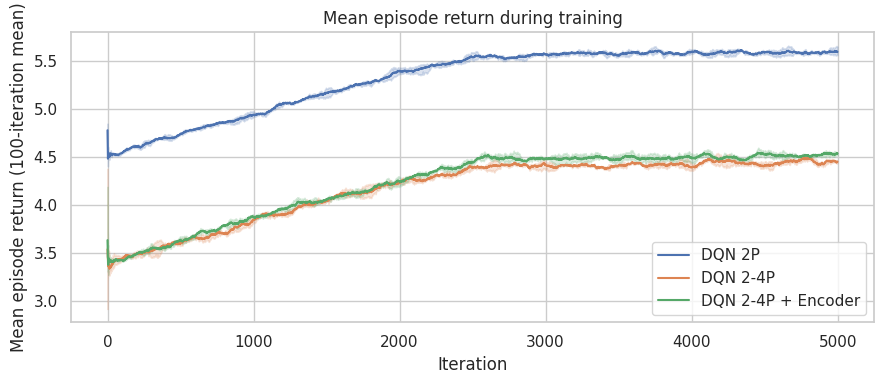

In [ ]:
plt.figure(figsize=(9, 4))
sns.lineplot(data=training_df, x="iteration", y="return_smoothed", hue="model")
plt.title("Mean episode return during training")
plt.xlabel("Iteration")
plt.ylabel("Mean episode return (100-iteration mean)")
plt.legend(title="")
plt.tight_layout()